# Notebook de dev pour l'entrainement vers MLflow

In [5]:
import logging
import numpy as np

import os
import mlflow
from mlflow import log_metric, log_param, log_artifacts
from random import random, randint
from datetime import datetime
import numpy as np

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
import time

from scipy.stats.mstats import winsorize

import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np

import boto3


from dotenv import load_dotenv
load_dotenv(override=True)


True

In [6]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [7]:
# mlflow.end_run()
# # ====================== SÉCURITÉ MLFLOW POUR NOTEBOOK ======================
# # partie spécifique dans les notebooks
# if mlflow.active_run():
#     mlflow.end_run()

# # Force la fermeture de tous les runs actifs
# while mlflow.active_run():
#     mlflow.end_run()

# print(" Tous les runs MLflow précédents ont été fermés.\n")
# # ====================== CONFIGURATION MLFLOW ======================

# mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI_TEAM"))

# EXPERIMENT_NAME = "ppml-retards-avion"

# # Création + récupération de l'ID (plus fiable que set_experiment seul)
# experiment = mlflow.set_experiment(EXPERIMENT_NAME)
# experiment_id = experiment.experiment_id   # ou mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id

# print(f"MLflow experiment : {EXPERIMENT_NAME} (ID: {experiment_id})\n")

# # Forcer l'experiment actif avec l'ID
# mlflow.set_experiment(experiment_id=experiment_id)



# 1. Chargement des données

### Option 1. Via SQL

### Option 2. Via CSV

In [8]:
# On va lire un fichier depuis S3
def get_s3_parquet(s3_key):
    session = boto3.Session(
        aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID_EQUIPE"),
        aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY_EQUIPE"),
        region_name=os.getenv("AWS_DEFAULT_REGION_EQUIPE", "eu-north-1")
    )
    bucket = os.getenv("BUCKET_EQUIPE")
    df= pd.read_parquet(f's3://{bucket}/{s3_key}')   
    return df



In [9]:

df_ppml = get_s3_parquet("prod/train/full_training_2025-10-05_to_2026-04-06.parquet")

df_ppml.columns

Index(['date', 'icao', 'type', 'flight_number', 'call_sign', 'status',
       'codeshare_status', 'is_cargo', 'scheduled_utc', 'revised_utc',
       'runway_utc', 'delay_minutes', 'terminal_dep', 'terminal_arr',
       'gate_dep', 'baggage_belt', 'destination_icao', 'destination_iata',
       'destination_name', 'airline_name', 'airline_iata', 'airline_icao',
       'aircraft_model', 'aircraft_reg', 'aircraft_mode_s', 'quality_dep',
       'quality_arr', 'aircraft_family', 'num_seats', 'is_widebody',
       'is_narrowbody', 'is_regional', 'aircraft_size_category',
       'is_freighter', 'is_holiday', 'vac_school', 'is_holiday_eve',
       'is_holiday_next', 'is_weekend', 'is_weekend_or_holiday',
       'holiday_name', 'temperature_2m', 'relative_humidity_2m',
       'wind_speed_10m', 'wind_gusts_10m', 'pressure_msl', 'precipitation',
       'cloud_cover'],
      dtype='object')

In [10]:

df_predict = get_s3_parquet("prod/predict/prediction_avril2026.parquet")

df_predict.columns

Index(['date', 'icao', 'type', 'flight_number', 'call_sign', 'status',
       'codeshare_status', 'is_cargo', 'scheduled_utc', 'revised_utc',
       'runway_utc', 'delay_minutes', 'terminal_dep', 'terminal_arr',
       'gate_dep', 'baggage_belt', 'destination_icao', 'destination_iata',
       'destination_name', 'airline_name', 'airline_iata', 'airline_icao',
       'aircraft_model', 'aircraft_reg', 'aircraft_mode_s', 'quality_dep',
       'quality_arr', 'aircraft_family', 'num_seats', 'is_widebody',
       'is_narrowbody', 'is_regional', 'aircraft_size_category',
       'is_freighter', 'is_holiday', 'vac_school', 'is_holiday_eve',
       'is_holiday_next', 'is_weekend', 'is_weekend_or_holiday',
       'holiday_name', 'temperature_2m', 'relative_humidity_2m',
       'wind_speed_10m', 'wind_gusts_10m', 'pressure_msl', 'precipitation',
       'cloud_cover'],
      dtype='object')

***

In [11]:
df_predict.scheduled_utc.min(), df_predict.scheduled_utc.max()

(Timestamp('2026-04-09 22:05:00'), Timestamp('2026-04-15 21:55:00'))

# 2. EDA initiale

### 1. Quelques stats

In [12]:
df_ppml.shape

(264759, 48)

In [13]:
df_ppml.describe()


,scheduled_utc,delay_minutes,num_seats,is_holiday,vac_school,is_holiday_eve,is_holiday_next,is_weekend,is_weekend_or_holiday,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_gusts_10m,pressure_msl,precipitation,cloud_cover
count,264759,250295.000000,264759.000000,264759.000000,264759.000000,264759.000000,264759.000000,264759.000000,264759.000000,264759.000000,264759.000000,264759.000000,264759.000000,264759.000000,264759.000000,264759.000000
mean,2026-01-21 06:12:46.287151616,15.806756,175.783535,0.041744,0.418947,0.038197,0.016793,0.247716,0.288957,8.320498,80.862675,12.969064,27.613549,1016.292819,0.075689,69.659660
min,2025-10-04 20:05:00,-695.000000,48.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-5.900000,25.000000,0.000000,1.100000,979.800000,0.000000,0.000000
25%,2025-12-18 17:25:00,-3.000000,135.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,72.000000,8.700000,18.700000,1011.400000,0.000000,33.000000
50%,2026-01-17 15:20:00,12.000000,165.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.900000,84.000000,12.100000,25.900000,1018.500000,0.000000,98.000000
75%,2026-03-03 06:35:00,26.000000,165.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,11.600000,92.000000,17.100000,35.600000,1022.500000,0.000000,100.000000
max,2026-04-06 10:05:00,1233.000000,525.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,23.700000,100.000000,38.700000,83.900000,1034.200000,9.300000,100.000000
std,NaN,32.446300,76.519658,0.200003,0.493388,0.191672,0.128494,0.431687,0.453279,4.803816,13.467027,5.909180,11.817885,8.942830,0.292108,39.745377


In [14]:
df_ppml.dtypes

date                              object
icao                              object
type                              object
flight_number                     object
call_sign                         object
status                            object
codeshare_status                  object
is_cargo                            bool
scheduled_utc             datetime64[ns]
revised_utc                       object
runway_utc                        object
delay_minutes                    float64
terminal_dep                      object
terminal_arr                      object
gate_dep                          object
baggage_belt                      object
destination_icao                  object
destination_iata                  object
destination_name                  object
airline_name                      object
airline_iata                      object
airline_icao                      object
aircraft_model                    object
aircraft_reg                      object
aircraft_mode_s 

In [15]:
df_predict.dtypes


date                              object
icao                              object
type                              object
flight_number                     object
call_sign                         object
status                            object
codeshare_status                  object
is_cargo                            bool
scheduled_utc             datetime64[ns]
revised_utc                       object
runway_utc                        object
delay_minutes                    float64
terminal_dep                      object
terminal_arr                      object
gate_dep                          object
baggage_belt                      object
destination_icao                  object
destination_iata                  object
destination_name                  object
airline_name                      object
airline_iata                      object
airline_icao                      object
aircraft_model                    object
aircraft_reg                      object
aircraft_mode_s 

### pour securité on verifie les types des colonnes en entree

In [16]:
df_ppml.head()

,date,icao,type,flight_number,call_sign,status,codeshare_status,is_cargo,scheduled_utc,revised_utc,runway_utc,delay_minutes,terminal_dep,terminal_arr,gate_dep,baggage_belt,destination_icao,destination_iata,destination_name,airline_name,airline_iata,airline_icao,aircraft_model,aircraft_reg,aircraft_mode_s,quality_dep,quality_arr,aircraft_family,num_seats,is_widebody,is_narrowbody,is_regional,aircraft_size_category,is_freighter,is_holiday,vac_school,is_holiday_eve,is_holiday_next,is_weekend,is_weekend_or_holiday,holiday_name,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_gusts_10m,pressure_msl,precipitation,cloud_cover
0,2025-10-05,LFPG,departure,BJ 521,LBT521,Departed,IsOperator,False,2025-10-04 20:05:00,2025-10-04 23:28Z,2025-10-04 23:28Z,203.0,3,None,None,None,DTTA,TUN,Tunis,Nouvelair Tunisie,BJ,LBT,Airbus A320,TS-INM,02A1AC,"[Basic, Live]",[],Airbus A320 Family,165,False,True,False,Medium,False,0,0,0,0,1,1,None,10.6,75,19.6,41.4,1013.8,0.0,23
1,2025-10-05,LFPG,departure,BJ 543,LBT543,Departed,IsOperator,False,2025-10-04 20:15:00,2025-10-04 22:35Z,2025-10-04 22:35Z,140.0,3,None,None,02,DTMB,MIR,Monastir,Nouvelair Tunisie,BJ,LBT,Airbus A320,TS-INR,02A1B1,"[Basic, Live]","[Basic, Live]",Airbus A320 Family,165,False,True,False,Medium,False,0,0,0,0,1,1,None,10.6,75,19.6,41.4,1013.8,0.0,23
2,2025-10-05,LFPG,departure,AF 406,AFR406,Departed,IsOperator,False,2025-10-04 21:20:00,2025-10-04 22:14Z,2025-10-04 22:14Z,54.0,2E,2,None,None,SCEL,SCL,Santiago,Air France,AF,AFR,Airbus A350-900,F-HTYT,39CF13,"[Basic, Live]",[Basic],Airbus A350,325,True,False,False,Very Large,False,0,0,0,0,1,1,None,10.4,77,19.9,38.9,1014.2,0.0,15
3,2025-10-05,LFPG,departure,AF 454,AFR454,Departed,IsOperator,False,2025-10-04 21:30:00,2025-10-04 22:03Z,2025-10-04 22:03Z,33.0,2E,3,None,None,SBGR,GRU,São Paulo,Air France,AF,AFR,Boeing 777-300,F-GSQY,394A18,"[Basic, Live]","[Basic, Live]",Boeing 777,355,True,False,False,Very Large,False,0,0,0,0,1,1,None,10.4,77,19.9,38.9,1014.2,0.0,15
4,2025-10-05,LFPG,departure,AF 116,AFR116,Departed,IsOperator,False,2025-10-04 21:45:00,2025-10-04 22:04Z,2025-10-04 22:04Z,19.0,2E,1,None,13,ZSPD,PVG,Shanghai,Air France,AF,AFR,Boeing 777,F-GZNS,3965B2,"[Basic, Live]","[Basic, Live]",Boeing 777,355,True,False,False,Very Large,False,0,0,0,0,1,1,None,10.1,77,19.9,38.9,1014.4,0.0,20


### Colonnes autorisées pour l'entraînement ET pour la prédiction
features_autorisees = [
    'icao', 'type', 'flight_number', 'codeshare_status', 'is_cargo',
    'scheduled_utc', 'terminal_dep', 'terminal_arr',
    'airline_name', 'aircraft_model', 'aircraft_family', 'aircraft_size_category',
    'num_seats', 'is_widebody', 'is_narrowbody', 'is_regional', 'is_freighter',
    'is_holiday', 'vac_school', 'is_holiday_eve', 'is_holiday_next', 'is_weekend',
    'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'wind_gusts_10m',
    'pressure_msl', 'precipitation', 'cloud_cover',
    'dest_icao_clean', 'dep_hour', 'dep_dayofweek', 'dep_month',
    'dep_hour_sin', 'dep_hour_cos', 'dep_dayofweek_sin', 'dep_dayofweek_cos', 
    'period_of_day'
]

### Colonnes a ABSOLUMENT supprimer du train (car leakage ou inutiles ex: quality)
cols_leakage = ['status', 'delay_minutes', 'revised_utc', 'runway_utc', 
                'gate_dep', 'baggage_belt', 'quality_dep', 'quality_arr']

### Colonnes vides dans le predict:


In [17]:
df_predict.head()

,date,icao,type,flight_number,call_sign,status,codeshare_status,is_cargo,scheduled_utc,revised_utc,runway_utc,delay_minutes,terminal_dep,terminal_arr,gate_dep,baggage_belt,destination_icao,destination_iata,destination_name,airline_name,airline_iata,airline_icao,aircraft_model,aircraft_reg,aircraft_mode_s,quality_dep,quality_arr,aircraft_family,num_seats,is_widebody,is_narrowbody,is_regional,aircraft_size_category,is_freighter,is_holiday,vac_school,is_holiday_eve,is_holiday_next,is_weekend,is_weekend_or_holiday,holiday_name,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_gusts_10m,pressure_msl,precipitation,cloud_cover
0,2026-04-10,LFMN,arrival,IB 1217,None,Expected,IsOperator,False,2026-04-09 22:05:00,None,None,NaN,4,1,K,None,None,None,None,Iberia,IB,IBE,Bombardier CRJ1000,None,None,"[Basic, Live]",[Basic],Bombardier CRJ,85,False,False,True,Small,False,0,1,0,0,0,0,None,14.5,91,4.3,9.7,1015.5,0.0,42
1,2026-04-10,LFMN,arrival,TP 484,None,Expected,IsOperator,False,2026-04-09 22:05:00,None,None,NaN,1,1,None,None,None,None,None,TAP Air Portugal,TP,TAP,Embraer 190,None,None,"[Basic, Live]",[Basic],Embraer E-Jet,100,False,True,True,Small,False,0,1,0,0,0,0,None,14.5,91,4.3,9.7,1015.5,0.0,42
2,2026-04-10,LFLL,arrival,V7 2919,None,Expected,IsOperator,False,2026-04-09 22:30:00,2026-04-09 22:30Z,None,0.0,PAX,1,D,None,None,None,None,Volotea,V7,VOE,Airbus A320,None,None,"[Basic, Live]","[Basic, Live]",Airbus A320 Family,165,False,True,False,Medium,False,0,1,0,0,0,0,None,13.7,67,3.9,7.9,1018.2,0.0,0
3,2026-04-10,LFPG,departure,LY 326,None,Expected,Unknown,False,2026-04-09 22:35:00,None,None,NaN,2B,None,None,None,None,None,Tel Aviv Yafo,El Al,LY,ELY,Boeing 787-9,None,None,[Basic],[],Boeing 787,295,True,False,False,Very Large,False,0,1,0,0,0,0,None,10.0,68,13.2,31.7,1021.5,0.0,100
4,2026-04-10,LFMN,arrival,U2 1616,None,Expected,IsOperator,False,2026-04-09 22:40:00,None,None,NaN,None,2,None,None,None,None,None,easyJet,U2,EZY,Airbus A320,None,None,[Basic],[Basic],Airbus A320 Family,165,False,True,False,Medium,False,0,1,0,0,0,0,None,14.2,91,4.1,7.9,1015.1,0.0,54


In [18]:
#colonnes avec valeurs manquantes
df_predict.isna().sum()
df_predict.isna().sum() / len(df_predict) * 100


date                        0.000000
icao                        0.000000
type                        0.000000
flight_number               0.000000
call_sign                  99.292214
status                      0.000000
codeshare_status            0.000000
is_cargo                    0.000000
scheduled_utc               0.000000
revised_utc                14.051792
runway_utc                100.000000
delay_minutes              14.051792
terminal_dep               23.132232
terminal_arr               23.104146
gate_dep                   97.826087
baggage_belt               97.505898
destination_icao           50.387597
destination_iata           50.387597
destination_name           50.224694
airline_name                0.000000
airline_iata                0.761150
airline_icao                0.800472
aircraft_model              0.342658
aircraft_reg               99.646107
aircraft_mode_s            99.646107
quality_dep                 0.000000
quality_arr                 0.000000
a

In [19]:
df_ppml.icao.nunique()                   

5

In [20]:
df_ppml.isna().sum() / len(df_ppml) * 100

date                       0.000000
icao                       0.000000
type                       0.000000
flight_number              0.000000
call_sign                 44.835492
status                     0.000000
codeshare_status           0.000000
is_cargo                   0.000000
scheduled_utc              0.000000
revised_utc                5.463082
runway_utc                88.357714
delay_minutes              5.463082
terminal_dep              20.097145
terminal_arr              19.644658
gate_dep                  78.859264
baggage_belt              84.859816
destination_icao          50.985991
destination_iata          50.985991
destination_name          50.865882
airline_name               0.000000
airline_iata               0.798840
airline_icao               0.783354
aircraft_model             0.335022
aircraft_reg              40.593899
aircraft_mode_s           39.874754
quality_dep                0.000000
quality_arr                0.000000
aircraft_family            0

### attention cas particuliers de previsions de mouvements aeroports!
on veut le status "Expected" sinon il a déjà été annulé, Retardé, ou erreur = arrivé pour une date dans le futur

In [21]:
print(df_predict.shape)
df_predict['status'].value_counts()


(35604, 48)


status
Expected    35432
Canceled      165
Delayed         4
Arrived         3
Name: count, dtype: int64

In [22]:
df_ppml["flight_number"].value_counts().head(30)

flight_number
AF 7300    97
KL 2078    96
AF 7313    96
AF 7371    95
AF 7302    95
AF 7301    93
AF 7304    92
AF 7362    88
AF 7330    82
U2 1631    82
AF 7343    82
AF 7363    80
DL 8495    80
AY 6312    79
U2 1632    79
AF 7331    79
AM 5923    79
AF 7360    78
AF 7336    77
U2 4860    77
U2 4859    77
AF 7305    77
FB 1562    77
VN 3183    77
AF 7310    76
DL 8340    76
AF 7312    76
KQ 3007    76
MU 1509    75
AF 7306    75
Name: count, dtype: int64

# 3. Nettoyage des données + features + drop colonnes

In [23]:
# =============================================
# 3. NETTOYAGE DES DONNÉES
# =============================================
def clean_data_train(df):
    print(f"Shape initial du dataset : {df.shape}")

    # 1. Suppression des vols sans information de retard (important)
    df_clean = df.dropna(subset=['delay_minutes']).copy()

    # 2. l'api ne remplit l'aeroport de destination (destination_icao) que pour les départs car les arrivées sont deduites de la colonne icao
    # on remet l'information pour le modele
    df_clean['dest_icao_clean'] = df_clean.apply(
        lambda row: row['icao'] if row['type'] == "arrival" else row['destination_icao'], 
        axis=1
    )

    print(f"Après suppression des lignes sans delay_minutes : {df_clean.shape[0]:,} lignes "
        f"({(df_clean.shape[0]/df.shape[0]*100):.1f}% conservés)")

    # 3. Traitement des valeurs manquantes restantes

    # a) Variables météo => imputation par la médiane
    meteo_cols = ['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m',
                'wind_gusts_10m', 'pressure_msl', 'precipitation', 'cloud_cover']

    for col in meteo_cols:
        if col in df_clean.columns:
            median_val = df_clean[col].median()
            df_clean[col] = df_clean[col].fillna(median_val)


    # dest_icao_clean (très peu de NaN)
    df_clean['dest_icao_clean'] = df_clean['dest_icao_clean'].fillna('UNKNOWN')

    # terminal_dep et terminal_arr (~20% NaN → on crée une vraie catégorie "inconnue")
    df_clean['terminal_dep'] = df_clean['terminal_dep'].fillna('UNKNOWN')
    df_clean['terminal_arr'] = df_clean['terminal_arr'].fillna('UNKNOWN')

    # aircraft_model (seulement 0.35% NaN → on prend la valeur la plus courante)
    most_common_model = df_clean['aircraft_model'].mode()[0]
    df_clean['aircraft_model'] = df_clean['aircraft_model'].fillna(most_common_model)

    print("NaN restants :")
    print(df_clean.isna().mean().sort_values(ascending=False))
    df_clean.head()
    # # =============================================
    # # 4. GESTION DES OUTLIERS sur delay_minutes
    # # =============================================

    # Version propre et recommandée
    lower = -30
    upper = 150

    df_clean['delay_minutes_clean'] = df_clean['delay_minutes'].clip(lower=lower, upper=upper)

    print("Statistiques après clipping recommandé :")
    print(df_clean['delay_minutes_clean'].describe())

    # Pourcentage de valeurs qui ont été modifiées
    modified = (df_clean['delay_minutes'] != df_clean['delay_minutes_clean']).mean() * 100
    print(f"\nPourcentage de lignes modifiées : {modified:.3f} %")

    df_fe = df_clean.copy()

    # 1. Convertir en datetime
    df_fe['scheduled_utc'] = pd.to_datetime(df_fe['scheduled_utc'])

    # 2. Features temporelles de base
    df_fe['dep_hour']       = df_fe['scheduled_utc'].dt.hour
    df_fe['dep_dayofweek']  = df_fe['scheduled_utc'].dt.dayofweek
    df_fe['dep_dayofmonth'] = df_fe['scheduled_utc'].dt.day
    df_fe['dep_month']      = df_fe['scheduled_utc'].dt.month

    # 3. Encodage cyclique 
    df_fe['dep_hour_sin'] = np.sin(2 * np.pi * df_fe['dep_hour'] / 24)
    df_fe['dep_hour_cos'] = np.cos(2 * np.pi * df_fe['dep_hour'] / 24)

    df_fe['dep_dayofweek_sin'] = np.sin(2 * np.pi * df_fe['dep_dayofweek'] / 7)
    df_fe['dep_dayofweek_cos'] = np.cos(2 * np.pi * df_fe['dep_dayofweek'] / 7)

    # 4. Période de la journée 
    df_fe['period_of_day'] = pd.cut(
        df_fe['dep_hour'], 
        bins=[0, 6, 10, 16, 20, 24], 
        labels=['night', 'morning', 'afternoon', 'evening', 'late_night'],   # 'night' → 'late_night'
        right=False,
        ordered=False   # Important labels identiques 
    )


    print("Feature Engineering terminé.")
    print(f"Shape final : {df_fe.shape}")
    print(f"Colonnes ajoutées : features temporelles")

    # Suppression des colonnes inutiles ou trop incomplètes (optionnel, à ajuster selon les besoins)
    colonnes_a_dropper = [
        "scheduled_utc",
        "flight_number",
        "date",
        "destination_icao",
        "destination_iata",
        "destination_name",
        "holiday_name",
        "runway_utc",
        "call_sign",
        "aircraft_reg",
        "aircraft_mode_s",
        "airline_iata",
        "airline_icao",
        "is_weekend_or_holiday",
        #leakage potentiel
        'status', 
        'delay_minutes',# cible remplacée par delay_minutes_clean 
        'revised_utc', 
        'runway_utc', 
        'gate_dep', 
        'baggage_belt', 
        'quality_dep', 
        'quality_arr'
    ]

    df_fe = df_fe.drop(columns=colonnes_a_dropper)

    return df_fe

***
dataset entrainement

In [24]:
df_fe= clean_data_train(df_ppml)

Shape initial du dataset : (264759, 48)
Après suppression des lignes sans delay_minutes : 250,295 lignes (94.5% conservés)
NaN restants :
holiday_name              0.957774
runway_utc                0.877105
baggage_belt              0.845406
gate_dep                  0.785150
destination_iata          0.506658
destination_icao          0.506658
destination_name          0.506175
call_sign                 0.442678
aircraft_reg              0.399325
aircraft_mode_s           0.391914
airline_iata              0.008338
airline_icao              0.008158
temperature_2m            0.000000
aircraft_size_category    0.000000
is_freighter              0.000000
is_holiday                0.000000
vac_school                0.000000
cloud_cover               0.000000
is_holiday_eve            0.000000
is_holiday_next           0.000000
relative_humidity_2m      0.000000
precipitation             0.000000
pressure_msl              0.000000
wind_gusts_10m            0.000000
wind_speed_10m        

In [36]:
print("Colonnes categorielles :")
print(df_fe.select_dtypes(include=['object', 'category']).nunique())
print("Colonnes numériques :")
print(df_fe.select_dtypes(include=np.number).columns.tolist())

Colonnes categorielles :
icao                        5
type                        2
codeshare_status            3
terminal_dep               38
terminal_arr               41
airline_name              256
aircraft_model            124
aircraft_family            16
aircraft_size_category      4
dest_icao_clean           365
period_of_day               5
dtype: int64
Colonnes numériques :
['num_seats', 'is_holiday', 'vac_school', 'is_holiday_eve', 'is_holiday_next', 'is_weekend', 'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'wind_gusts_10m', 'pressure_msl', 'precipitation', 'cloud_cover', 'delay_minutes_clean', 'dep_hour', 'dep_dayofweek', 'dep_dayofmonth', 'dep_month', 'dep_hour_sin', 'dep_hour_cos', 'dep_dayofweek_sin', 'dep_dayofweek_cos']


In [26]:
df_fe.isna().sum() / len(df_fe) * 100

icao                      0.0
type                      0.0
codeshare_status          0.0
is_cargo                  0.0
terminal_dep              0.0
terminal_arr              0.0
airline_name              0.0
aircraft_model            0.0
aircraft_family           0.0
num_seats                 0.0
is_widebody               0.0
is_narrowbody             0.0
is_regional               0.0
aircraft_size_category    0.0
is_freighter              0.0
is_holiday                0.0
vac_school                0.0
is_holiday_eve            0.0
is_holiday_next           0.0
is_weekend                0.0
temperature_2m            0.0
relative_humidity_2m      0.0
wind_speed_10m            0.0
wind_gusts_10m            0.0
pressure_msl              0.0
precipitation             0.0
cloud_cover               0.0
dest_icao_clean           0.0
delay_minutes_clean       0.0
dep_hour                  0.0
dep_dayofweek             0.0
dep_dayofmonth            0.0
dep_month                 0.0
dep_hour_s

***
dataset PREDICT

In [27]:
# =============================================
# 3. NETTOYAGE DES DONNÉES
# =============================================
def clean_data_pred(df):
    
    print(f"Shape initial du dataset : {df.shape}")
    #on ne garde que les vols futurs 'expected' et non canceled, delayed etc...
    df_predict_expected = df[df['status'] == 'Expected']

    # delay_minutes est supprimé du dataset de prédiction car c'est la cible à prédire, il n'est pas renseigné dans ce dataset
    df_clean = df_predict_expected.drop(columns=['delay_minutes'], errors='ignore').copy()

    # 2. l'api ne remplit l'aeroport de destination (destination_icao) que pour les départs car les arrivées sont deduites de la colonne icao
    # on remet l'information pour le modele
    df_clean['dest_icao_clean'] = df_clean.apply(
        lambda row: row['icao'] if row['type'] == "arrival" else row['destination_icao'], 
        axis=1
    )


    # dest_icao_clean (très peu de NaN sur type departure)
    df_clean['dest_icao_clean'] = df_clean['dest_icao_clean'].fillna('UNKNOWN')

    # terminal_dep et terminal_arr (~20% NaN → on crée une vraie catégorie "inconnue")
    df_clean['terminal_dep'] = df_clean['terminal_dep'].fillna('UNKNOWN')
    df_clean['terminal_arr'] = df_clean['terminal_arr'].fillna('UNKNOWN')

    # aircraft_model (seulement 0.35% NaN → on prend la valeur la plus courante)
    most_common_model = df_clean['aircraft_model'].mode()[0]
    df_clean['aircraft_model'] = df_clean['aircraft_model'].fillna(most_common_model)

   

    # Traitement des valeurs manquantes restantes

    # a) Variables météo => imputation par la médiane
    meteo_cols = ['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m',
                'wind_gusts_10m', 'pressure_msl', 'precipitation', 'cloud_cover']

    for col in meteo_cols:
        if col in df_clean.columns:
            median_val = df_clean[col].median()
            df_clean[col] = df_clean[col].fillna(median_val)

    # on ne gère plus delay_minutes (cible absente du dataset de prédiction)


    df_fe = df_clean.copy()

    # 1. Convertir en datetime
    df_fe['scheduled_utc'] = pd.to_datetime(df_fe['scheduled_utc'])

    # 2. Features temporelles de base
    df_fe['dep_hour']       = df_fe['scheduled_utc'].dt.hour
    df_fe['dep_dayofweek']  = df_fe['scheduled_utc'].dt.dayofweek
    df_fe['dep_dayofmonth'] = df_fe['scheduled_utc'].dt.day
    df_fe['dep_month']      = df_fe['scheduled_utc'].dt.month

    # 3. Encodage cyclique 
    df_fe['dep_hour_sin'] = np.sin(2 * np.pi * df_fe['dep_hour'] / 24)
    df_fe['dep_hour_cos'] = np.cos(2 * np.pi * df_fe['dep_hour'] / 24)

    df_fe['dep_dayofweek_sin'] = np.sin(2 * np.pi * df_fe['dep_dayofweek'] / 7)
    df_fe['dep_dayofweek_cos'] = np.cos(2 * np.pi * df_fe['dep_dayofweek'] / 7)

    # 4. Période de la journée 
    df_fe['period_of_day'] = pd.cut(
        df_fe['dep_hour'], 
        bins=[0, 6, 10, 16, 20, 24], 
        labels=['night', 'morning', 'afternoon', 'evening', 'late_night'],   # 'night' → 'late_night'
        right=False,
        ordered=False   # Important labels identiques 
    )


    print("Feature Engineering terminé.")
    print(f"Shape final : {df_fe.shape}")
    print(f"Colonnes ajoutées : features temporelles")

    # Suppression des colonnes inutiles ou trop incomplètes (optionnel, à ajuster selon les besoins)
    colonnes_a_dropper = [
        "scheduled_utc",
        "flight_number",
        "date",
        "destination_icao",
        "destination_iata",
        "destination_name",
        "holiday_name",
        "runway_utc",
        "call_sign",
        "aircraft_reg",
        "aircraft_mode_s",
        "airline_iata",
        "airline_icao",
        "is_weekend_or_holiday",
        #leakage potentiel
        'status', 
        'delay_minutes',# deja dropée mais on applique le meme drop que sur le train par principe de précaution 
        'revised_utc', 
        'runway_utc', 
        'gate_dep', 
        'baggage_belt', 
        'quality_dep', 
        'quality_arr'
    ]

    df_fe = df_fe.drop(columns=colonnes_a_dropper, errors='ignore')
    print("NaN restants :")
    print(df_fe.isna().mean().sort_values(ascending=False))
    return df_fe

In [28]:
df_pred= clean_data_pred(df_predict)

Shape initial du dataset : (35604, 48)
Feature Engineering terminé.
Shape final : (35432, 57)
Colonnes ajoutées : features temporelles
NaN restants :
icao                      0.0
is_weekend                0.0
relative_humidity_2m      0.0
wind_speed_10m            0.0
wind_gusts_10m            0.0
pressure_msl              0.0
precipitation             0.0
cloud_cover               0.0
dest_icao_clean           0.0
dep_hour                  0.0
dep_dayofweek             0.0
dep_dayofmonth            0.0
dep_month                 0.0
dep_hour_sin              0.0
dep_hour_cos              0.0
dep_dayofweek_sin         0.0
dep_dayofweek_cos         0.0
temperature_2m            0.0
is_holiday_next           0.0
type                      0.0
is_holiday_eve            0.0
codeshare_status          0.0
is_cargo                  0.0
terminal_dep              0.0
terminal_arr              0.0
airline_name              0.0
aircraft_model            0.0
aircraft_family           0.0
num_seats 

In [29]:
df_pred.icao.nunique()

5

In [34]:
print("Colonnes categorielles :")
print(df_pred.select_dtypes(include=['object', 'category']).nunique())
print("Colonnes numériques :")
print(df_pred.select_dtypes(include=np.number).columns.tolist())

Colonnes categorielles :
icao                        5
type                        2
codeshare_status            3
terminal_dep               30
terminal_arr               28
airline_name              154
aircraft_model             47
aircraft_family            15
aircraft_size_category      4
dest_icao_clean           326
period_of_day               5
dtype: int64
Colonnes numériques :
['num_seats', 'is_holiday', 'vac_school', 'is_holiday_eve', 'is_holiday_next', 'is_weekend', 'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'wind_gusts_10m', 'pressure_msl', 'precipitation', 'cloud_cover', 'dep_hour', 'dep_dayofweek', 'dep_dayofmonth', 'dep_month', 'dep_hour_sin', 'dep_hour_cos', 'dep_dayofweek_sin', 'dep_dayofweek_cos']


## Plus de nan dans les datasets train et predict
***

## visus

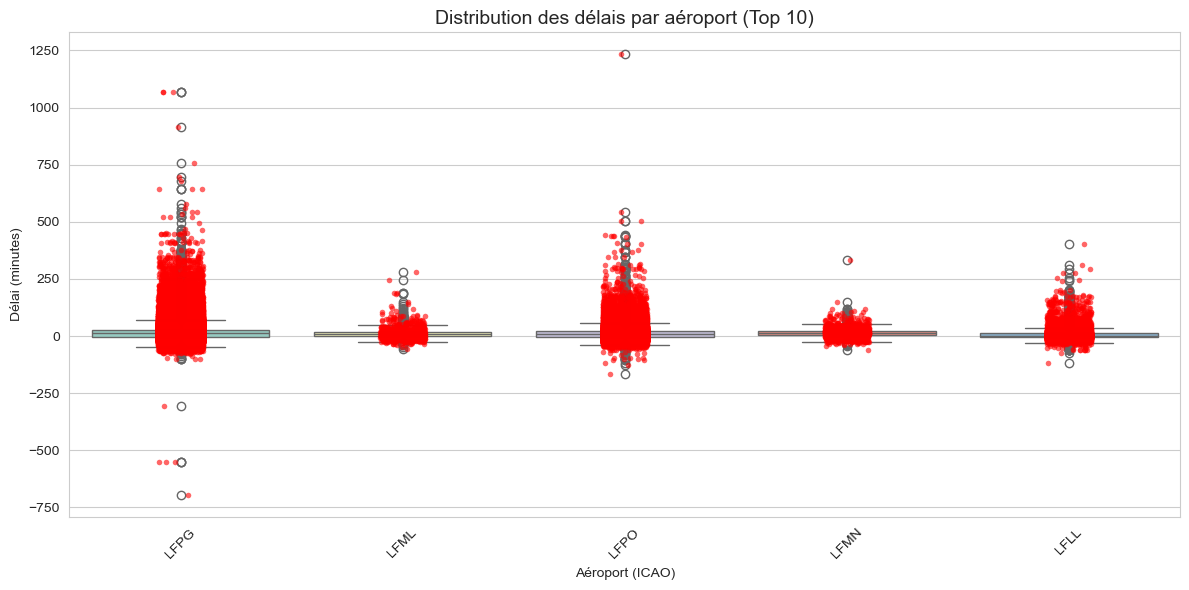

In [41]:
# Graphique des délais par aéroport (Top 10)
top_airports = df_ppml['icao'].value_counts().head(10).index

plt.figure(figsize=(12, 6))

sns.boxplot(data=df_ppml[df_ppml['icao'].isin(top_airports)], 
            x='icao', 
            y='delay_minutes',          # ou 'delay_minutes_clean' selon ton df
            hue='icao',                 # ← AJOUTÉ
            palette="Set3",
            legend=False)               # ← AJOUTÉ

sns.stripplot(data=df_ppml[df_ppml['icao'].isin(top_airports)], 
              x='icao', 
              y='delay_minutes',
              color='red', 
              size=4, 
              alpha=0.6, 
              jitter=True)

plt.title("Distribution des délais par aéroport (Top 10)", fontsize=14)
plt.ylabel("Délai (minutes)")
plt.xlabel("Aéroport (ICAO)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

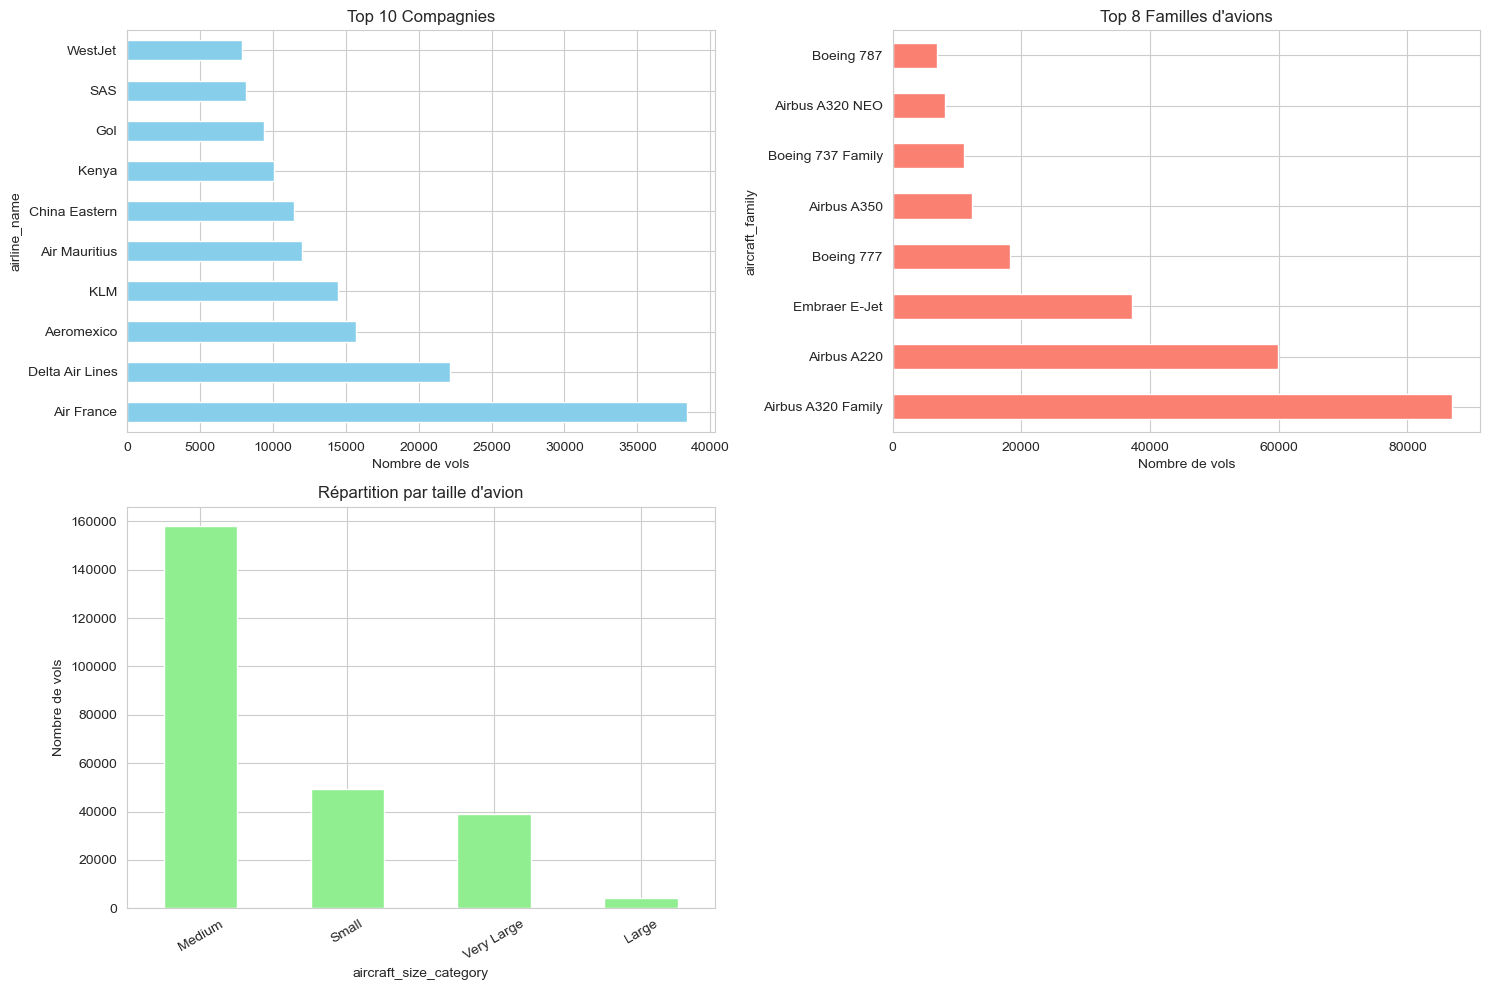

In [44]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
df_fe['airline_name'].value_counts().head(10).plot(kind='barh', color='skyblue')
plt.title("Top 10 Compagnies")
plt.xlabel("Nombre de vols")

plt.subplot(2, 2, 2)
df_fe['aircraft_family'].value_counts().head(8).plot(kind='barh', color='salmon')
plt.title("Top 8 Familles d'avions")
plt.xlabel("Nombre de vols")

plt.subplot(2, 2, 3)
df_fe['aircraft_size_category'].value_counts().plot(kind='bar', color='lightgreen')
plt.title("Répartition par taille d'avion")
plt.ylabel("Nombre de vols")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

# 6. Modélisation

# Envoi de modèle 

In [ ]:
from category_encoders import TargetEncoder
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import mlflow
import mlflow.catboost
import os
def train_catboost(
    df,
    run_name: str = "CatBoost_Baseline",
    iterations: int = 6000,           # Nombre d'arbres (plus = modèle plus puissant)
    learning_rate: float = 0.06,      # Taux d'apprentissage : contrôle la vitesse de convergence
    depth: int = 8,                   # Profondeur des arbres (plus élevé = capture plus d'interactions)
    eval_metric: str = 'RMSE',        # Métrique utilisée pour l'early stopping et l'affichage
    early_stopping_rounds: int = 300, # Arrête l'entraînement si pas d'amélioration pendant X itérations
    l2_leaf_reg: float = 3,           # Régularisation L2 (anti-overfitting) va limiter les valeurs extrêmes des feuilles
    random_strength: float = 1.0,     # Ajoute du bruit pour plus de robustesse.le bruit aléatoire peut aider à éviter que le modèle ne s'adapte trop étroitement aux données d'entraînement.
    bagging_temperature: float = 0.7  # Température de bagging pour plus de diversité dans les arbres. 
    # Le bagging est une technique qui consiste à entraîner chaque arbre sur un échantillon aléatoire des données (avec remplacement). 
    # La température contrôle la diversité de ces échantillons : plus elle est basse, plus les arbres seront similaires (moins de diversité), 
    # tandis qu'une température plus élevée encouragera une plus grande diversité entre les arbres, ce qui peut améliorer la généralisation du modèle.
):

    with mlflow.start_run(run_name=run_name) as run:
        
        df_model = df.copy()
        X = df_model.drop(columns=['delay_minutes_clean'])
        y = df_model['delay_minutes_clean']
        
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=0.20, random_state=42
        )

        # ====================== FEATURES CATEGORIELLES ======================
        categorical_features = [
            'icao', 'type', 'codeshare_status',
            'terminal_dep', 'terminal_arr',
            'aircraft_family', 'aircraft_size_category',
            'period_of_day',
            'airline_name',      # ← à remettre ici
            'dest_icao_clean',   # ← à remettre ici
            'aircraft_model'     # ← à remettre ici
        ]

        # ====================== POOLS ======================
        train_pool = Pool(X_train, y_train, cat_features=categorical_features)
        val_pool   = Pool(X_val,   y_val,   cat_features=categorical_features)

        # ====================== MODELE ======================
        model = CatBoostRegressor(
            iterations=iterations,
            learning_rate=learning_rate,
            depth=depth,
            loss_function='RMSE',
            eval_metric=eval_metric,
            random_seed=42,
            early_stopping_rounds=early_stopping_rounds,
            verbose=200,
            task_type='GPU',
            l2_leaf_reg=l2_leaf_reg,
            random_strength=random_strength,
            bagging_temperature=bagging_temperature
        )

        model.fit(train_pool, eval_set=val_pool, use_best_model=True)

        #=============================================
        # 5. Évaluation
        # =============================================
        preds = model.predict(X_val)
        mae = mean_absolute_error(y_val, preds)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        r2 = r2_score(y_val, preds)

        # Logging des métriques
        mlflow.log_metric("MAE", round(mae, 4))
        mlflow.log_metric("RMSE", round(rmse, 4))
        mlflow.log_metric("R2", round(r2, 4))
        mlflow.log_metric("best_iteration", model.get_best_iteration())

        # =============================================
        # 6. FEATURE IMPORTANCE
        # =============================================
        print("Calcul et logging des feature importances...")

        import pandas as pd
        import matplotlib.pyplot as plt
        import seaborn as sns

        # Récupération des noms des features finales (après Target Encoding + drop)
        feature_names = X_train.columns.tolist()

        # Feature importance par défaut de CatBoost (PredictionValuesChange)
        feature_importance = model.get_feature_importance()

        # DataFrame pour faciliter le logging
        fi_df = pd.DataFrame({
            'feature': feature_names,
            'importance': feature_importance
        }).sort_values(by='importance', ascending=False)

        # 1. Log du tableau complet en CSV
        fi_df.to_csv("feature_importance.csv", index=False)
        mlflow.log_artifact("feature_importance.csv", artifact_path="feature_importance")

        # 2. Log d'un tableau interactif (visible directement dans l'UI MLflow)
        mlflow.log_table(fi_df.head(30), artifact_file="feature_importance_top30.json")

        # 3. Graphique (dans l'onglet Artifacts)
        plt.figure(figsize=(14, 10))
        sns.barplot(
            data=fi_df.head(20),
            x='importance',
            y='feature',
            palette="viridis"
        )
        plt.title(f"Top 20 Feature Importance - {run_name}")
        plt.xlabel("Importance Score")
        plt.ylabel("Features")
        plt.tight_layout()

        plt.savefig("feature_importance_plot.png", dpi=220, bbox_inches='tight')
        mlflow.log_artifact("feature_importance_plot.png", artifact_path="feature_importance")
        plt.close()

        print(f" Feature importance loguée ({len(feature_names)} features)")

        # Logging du modèle CatBoost (important pour l'API)
        # === LOGGING DU MODÈLE DANS LE REGISTRY ===
        model_info = mlflow.catboost.log_model(
            cb_model=model,
            artifact_path="catboost_model",
            registered_model_name="CatBoost_Delay_Prediction"   # ← Ce nom apparaîtra dans l'onglet Models
        )

        print(f" Modèle enregistré dans le Model Registry : CatBoost_Delay_Prediction")
        print(f"   Version : {model_info.registered_model_version if hasattr(model_info, 'registered_model_version') else 'N/A'}")

        # Logging des paramètres du modèle
        mlflow.log_params({
            "iterations": iterations,
            "learning_rate": learning_rate,
            "depth": depth,
            "eval_metric": eval_metric,
            "early_stopping_rounds": early_stopping_rounds,
            "l2_leaf_reg": l2_leaf_reg,
            "random_strength": random_strength,
            "bagging_temperature": bagging_temperature,
            "use_target_encoding": True
        })

        print(f"\n=== Résultats : {run_name} ===")
        print(f"MAE   : {mae:.3f} minutes")
        print(f"RMSE  : {rmse:.3f} minutes")
        print(f"R²    : {r2:.4f}")
        print(f"Best iteration : {model.get_best_iteration()}")
        print("="*50 + "\n")

In [38]:
# # ====================== EXEMPLES D'UTILISATION ======================
# df_model = df_fe.copy()
# # Exemple 1 : Baseline avec paramètres par défaut
# model1 = train_catboost(df_model)


In [ ]:
model4 = train_catboost(
    df=df_fe,
    run_name="test8",
    iterations=10000,
    learning_rate=0.055,
    depth=9
) 


0:	learn: 28.2822639	test: 28.2912258	best: 28.2912258 (0)	total: 56.1ms	remaining: 9m 21s
200:	learn: 22.1377196	test: 22.4091339	best: 22.4091339 (200)	total: 10.9s	remaining: 8m 53s
400:	learn: 21.2946002	test: 21.8010184	best: 21.8010184 (400)	total: 20.9s	remaining: 8m 19s
600:	learn: 20.6295666	test: 21.3451075	best: 21.3451075 (600)	total: 33.1s	remaining: 8m 37s
800:	learn: 20.0242048	test: 20.9439126	best: 20.9439126 (800)	total: 48.3s	remaining: 9m 15s
1000:	learn: 19.4811912	test: 20.5792843	best: 20.5792843 (1000)	total: 1m	remaining: 9m
1200:	learn: 19.0234962	test: 20.2936226	best: 20.2936226 (1200)	total: 1m 14s	remaining: 9m 8s
1400:	learn: 18.6030125	test: 20.0431246	best: 20.0431246 (1400)	total: 1m 32s	remaining: 9m 26s
1600:	learn: 18.2273405	test: 19.8161439	best: 19.8161439 (1600)	total: 1m 50s	remaining: 9m 39s
1800:	learn: 17.8615659	test: 19.6047879	best: 19.6047879 (1800)	total: 2m	remaining: 9m 8s
2000:	learn: 17.5403932	test: 19.4269725	best: 19.4269725 (200

C:\Users\Oo-k\AppData\Local\Temp\ipykernel_19164\2032043712.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
2026/04/13 14:52:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


 Feature importance loguée (37 features)


Registered model 'CatBoost_Delay_Prediction' already exists. Creating a new version of this model...
2026/04/13 14:52:59 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: CatBoost_Delay_Prediction, version 2
Created version '2' of model 'CatBoost_Delay_Prediction'.


 Modèle enregistré dans le Model Registry : CatBoost_Delay_Prediction
   Version : 2

=== Résultats : test8 ===
MAE   : 10.029 minutes
RMSE  : 16.262 minutes
R²    : 0.6792
Best iteration : 9999

🏃 View run test8 at: https://stoneray-ppml-mlflow.hf.space/#/experiments/1/runs/743bf3fae6024201bc2f30f88eed3524
🧪 View experiment at: https://stoneray-ppml-mlflow.hf.space/#/experiments/1


In [140]:
print("df_fe")
df_fe.head()

df_fe


,icao,type,codeshare_status,is_cargo,terminal_dep,terminal_arr,airline_name,aircraft_model,aircraft_family,num_seats,is_widebody,is_narrowbody,is_regional,aircraft_size_category,is_freighter,is_holiday,vac_school,is_holiday_eve,is_holiday_next,is_weekend,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_gusts_10m,pressure_msl,precipitation,cloud_cover,dest_icao_clean,delay_minutes_clean,dep_hour,dep_dayofweek,dep_dayofmonth,dep_month,dep_hour_sin,dep_hour_cos,dep_dayofweek_sin,dep_dayofweek_cos,period_of_day
0,LFPG,departure,IsOperator,False,3,UNKNOWN,Nouvelair Tunisie,Airbus A320,Airbus A320 Family,165,False,True,False,Medium,False,0,0,0,0,1,10.6,75,19.6,41.4,1013.8,0.0,23,DTTA,150.0,20,5,4,10,-0.866025,0.500000,-0.974928,-0.222521,late_night
1,LFPG,departure,IsOperator,False,3,UNKNOWN,Nouvelair Tunisie,Airbus A320,Airbus A320 Family,165,False,True,False,Medium,False,0,0,0,0,1,10.6,75,19.6,41.4,1013.8,0.0,23,DTMB,140.0,20,5,4,10,-0.866025,0.500000,-0.974928,-0.222521,late_night
2,LFPG,departure,IsOperator,False,2E,2,Air France,Airbus A350-900,Airbus A350,325,True,False,False,Very Large,False,0,0,0,0,1,10.4,77,19.9,38.9,1014.2,0.0,15,SCEL,54.0,21,5,4,10,-0.707107,0.707107,-0.974928,-0.222521,late_night
3,LFPG,departure,IsOperator,False,2E,3,Air France,Boeing 777-300,Boeing 777,355,True,False,False,Very Large,False,0,0,0,0,1,10.4,77,19.9,38.9,1014.2,0.0,15,SBGR,33.0,21,5,4,10,-0.707107,0.707107,-0.974928,-0.222521,late_night
4,LFPG,departure,IsOperator,False,2E,1,Air France,Boeing 777,Boeing 777,355,True,False,False,Very Large,False,0,0,0,0,1,10.1,77,19.9,38.9,1014.4,0.0,20,ZSPD,19.0,21,5,4,10,-0.707107,0.707107,-0.974928,-0.222521,late_night


In [141]:
print("df_pred")
df_pred.head()

df_pred


,icao,type,codeshare_status,is_cargo,terminal_dep,terminal_arr,airline_name,aircraft_model,aircraft_family,num_seats,is_widebody,is_narrowbody,is_regional,aircraft_size_category,is_freighter,is_holiday,vac_school,is_holiday_eve,is_holiday_next,is_weekend,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_gusts_10m,pressure_msl,precipitation,cloud_cover,dest_icao_clean,dep_hour,dep_dayofweek,dep_dayofmonth,dep_month,dep_hour_sin,dep_hour_cos,dep_dayofweek_sin,dep_dayofweek_cos,period_of_day
0,LFMN,arrival,IsOperator,False,4,1,Iberia,Bombardier CRJ1000,Bombardier CRJ,85,False,False,True,Small,False,0,1,0,0,0,14.5,91,4.3,9.7,1015.5,0.0,42,LFMN,22,3,9,4,-0.5,0.866025,0.433884,-0.900969,late_night
1,LFMN,arrival,IsOperator,False,1,1,TAP Air Portugal,Embraer 190,Embraer E-Jet,100,False,True,True,Small,False,0,1,0,0,0,14.5,91,4.3,9.7,1015.5,0.0,42,LFMN,22,3,9,4,-0.5,0.866025,0.433884,-0.900969,late_night
2,LFLL,arrival,IsOperator,False,PAX,1,Volotea,Airbus A320,Airbus A320 Family,165,False,True,False,Medium,False,0,1,0,0,0,13.7,67,3.9,7.9,1018.2,0.0,0,LFLL,22,3,9,4,-0.5,0.866025,0.433884,-0.900969,late_night
3,LFPG,departure,Unknown,False,2B,UNKNOWN,El Al,Boeing 787-9,Boeing 787,295,True,False,False,Very Large,False,0,1,0,0,0,10.0,68,13.2,31.7,1021.5,0.0,100,UNKNOWN,22,3,9,4,-0.5,0.866025,0.433884,-0.900969,late_night
4,LFMN,arrival,IsOperator,False,UNKNOWN,2,easyJet,Airbus A320,Airbus A320 Family,165,False,True,False,Medium,False,0,1,0,0,0,14.2,91,4.1,7.9,1015.1,0.0,54,LFMN,22,3,9,4,-0.5,0.866025,0.433884,-0.900969,late_night


### petit test de prediction en local avec le dataset de prediction

In [ ]:
def make_predictions(df_pred_raw, output_filename="predictions_result.csv", model=None, te=None):
    """
    Prépare le df_pred et retourne les prédictions.
    """
    df = df_pred_raw.copy()
    
    print(f"Dataset de départ : {df.shape[0]} lignes")
    
   # Attention le dataset de predict doit etre préparé de maniere a etre ISO avec le dataset d'entrainement (meme features, meme preprocessing) 
   # pour que le modèle puisse faire des prédictions correctes*
    # ====================== TARGET ENCODING ======================
    high_card_cols = ['airline_name', 'dest_icao_clean', 'aircraft_model']
    
    print("Application du TargetEncoder...")
    X_pred = te.transform(df)
    X_pred = X_pred.drop(columns=high_card_cols, errors='ignore')
    
    # Nettoyage des catégorielles restantes
    categorical_features = [
        'icao', 'type', 'codeshare_status', 'terminal_dep', 'terminal_arr',
        'aircraft_family', 'aircraft_size_category', 'period_of_day'
    ]
    
    
    # ====================== PRÉDICTION ======================
    print("Génération des prédictions...")
    pred_pool = Pool(X_pred, cat_features=[col for col in categorical_features if col in X_pred.columns])
    
    predictions = model.predict(pred_pool)
    
    # Ajout des résultats
    df_result = df.copy()
    df_result['predicted_delay_minutes'] = predictions.round(2)
    
    # Statistiques rapides
    print("\n=== Statistiques des prédictions ===")
    print(f"Nombre de prédictions : {len(predictions)}")
    print(f"Délai moyen prédit    : {predictions.mean():.2f} minutes")
    print(f"Délai médian prédit   : {np.median(predictions):.2f} minutes")
    print(f"Délai max prédit      : {predictions.max():.1f} minutes")
    print(f"Délai min prédit      : {predictions.min():.1f} minutes")
    
    # Distribution par tranche
    bins = [0, 15, 30, 60, 120, 300, float('inf')]
    labels = ['0-15min', '15-30min', '30-60min', '1-2h', '2-5h', '>5h']
    df_result['bucket'] = pd.cut(df_result['predicted_delay_minutes'], bins=bins, labels=labels, right=False)
    print("\nDistribution des prédictions :")
    print(df_result['bucket'].value_counts().sort_index())
    
    # Sauvegarde
    df_result.to_csv(output_filename, index=False)
    print(f"\n✅ Fichier sauvegardé : {output_filename}")
    
    # Affichage des 10 premiers exemples
    #cols_to_show = ['icao', 'airline_name', 'aircraft_model', 'dep_hour', 'predicted_delay_minutes']
    print("\nExemples de prédictions :")
    # print(df_result[cols_to_show].head(10))
    print(df_result.head(10))
    print(df_result.columns)
    
    return df_result

In [142]:
run_id = "4028f4177e41453cbf22296d14848726"   # dans l'UI MLflow
modele_ml = mlflow.catboost.load_model(f"runs:/{run_id}/catboost_model")
te = mlflow.sklearn.load_model(f"runs:/{run_id}/target_encoder")

In [147]:
prediction= make_predictions(df_pred,model=modele_ml, te=te)

Dataset de départ : 35432 lignes
Application du TargetEncoder...
Génération des prédictions...

=== Statistiques des prédictions ===
Nombre de prédictions : 35432
Délai moyen prédit    : 12.97 minutes
Délai médian prédit   : 13.18 minutes
Délai max prédit      : 92.2 minutes
Délai min prédit      : -31.9 minutes

Distribution des prédictions :
bucket
0-15min     10689
15-30min    12044
30-60min     4423
1-2h           45
2-5h            0
>5h             0
Name: count, dtype: int64

✅ Fichier sauvegardé : predictions_result.csv

Exemples de prédictions :
   icao       type codeshare_status  is_cargo terminal_dep terminal_arr  \
0  LFMN    arrival       IsOperator     False            4            1   
1  LFMN    arrival       IsOperator     False            1            1   
2  LFLL    arrival       IsOperator     False          PAX            1   
3  LFPG  departure          Unknown     False           2B      UNKNOWN   
4  LFMN    arrival       IsOperator     False      UNKNOWN      

### colonnes preds 
Index(['icao', 'type', 'codeshare_status', 'is_cargo', 'terminal_dep',
       'terminal_arr', 'airline_name', 'aircraft_model', 'aircraft_family',
       'num_seats', 'is_widebody', 'is_narrowbody', 'is_regional',
       'aircraft_size_category', 'is_freighter', 'is_holiday', 'vac_school',
       'is_holiday_eve', 'is_holiday_next', 'is_weekend', 'temperature_2m',
       'relative_humidity_2m', 'wind_speed_10m', 'wind_gusts_10m',
       'pressure_msl', 'precipitation', 'cloud_cover', 'dest_icao_clean',
       'dep_hour', 'dep_dayofweek', 'dep_dayofmonth', 'dep_month',
       'dep_hour_sin', 'dep_hour_cos', 'dep_dayofweek_sin',
       'dep_dayofweek_cos', 'period_of_day', 'predicted_delay_minutes',
       'bucket'],
      dtype='object')

In [ ]:
# mlflow.end_run()

In [ ]:
# # Set your variables for your environment
# EXPERIMENT_NAME="ppml-mlflow-experiment"

# # Set tracking URI to your Hugging Face application
# mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])

# # Set experiment's info
# mlflow.set_experiment(EXPERIMENT_NAME)

# # Get our experiment info
# experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)


# with mlflow.start_run(experiment_id = experiment.experiment_id):

#     # Instanciate and fit the model
#     lr = LogisticRegression()
#     lr.fit(X_train, y_train)

#     # Store metrics
#     predicted_qualities = lr.predict(X_test)
#     accuracy = lr.score(X_test, y_test)

#     # Print results
#     print("LogisticRegression model")
#     print("Accuracy: {}".format(accuracy))


### Ajout des métriques

In [ ]:
# mlflow.log_metric("METRIC_NAME", metric)

In [ ]:
# # Set your variables for your environment
# EXPERIMENT_NAME="my-first-mlflow-experiment"

# # Set tracking URI to your Hugging Face application
# mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])

# # Set experiment's info
# mlflow.set_experiment(EXPERIMENT_NAME)

# # Get our experiment info
# experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

# # Call mlflow autolog
# mlflow.sklearn.autolog()

# with mlflow.start_run(experiment_id = experiment.experiment_id):
#     # Instanciate and fit the model
#     lr = LogisticRegression()
#     lr.fit(X_train, y_train)

#     # Store metrics
#     predicted_qualities = lr.predict(X_test)
#     accuracy = lr.score(X_test, y_test)

#     # Print results
#     print("LogisticRegression model")
#     print("Accuracy: {}".format(accuracy))

#     # Log Metric
#     mlflow.log_metric("Accuracy", accuracy)


### On peut aussi logger les paramètres

In [ ]:
# mlflow.log_param("PARAM_NAME", param)

In [ ]:
# # Set your variables for your environment
# EXPERIMENT_NAME="my-first-mlflow-experiment"

# # Set tracking URI to your Hugging Face application
# mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])

# # Set experiment's info
# mlflow.set_experiment(EXPERIMENT_NAME)

# # Get our experiment info
# experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

# # Call mlflow autolog
# mlflow.sklearn.autolog()

# with mlflow.start_run(experiment_id = experiment.experiment_id):
#     # Specified Parameters
#     c = 0.5

#     # Instanciate and fit the model
#     lr = LogisticRegression(C=c)
#     lr.fit(X_train.values, y_train.values)

#     # Store metrics
#     predicted_qualities = lr.predict(X_test.values)
#     accuracy = lr.score(X_test.values, y_test.values)

#     # Print results
#     print("LogisticRegression model")
#     print("Accuracy: {}".format(accuracy))

#     # Log Metric
#     mlflow.log_metric("Accuracy", accuracy)

#     # Log Param
#     mlflow.log_param("C", c)


### Logger le modele MLflow

In [ ]:
# # Set your variables for your environment
# EXPERIMENT_NAME="my-first-mlflow-experiment"

# # Set tracking URI to your Hugging Face application
# mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])

# # Set experiment's info
# mlflow.set_experiment(EXPERIMENT_NAME)

# # Get our experiment info
# experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

# # Call mlflow autolog
# mlflow.sklearn.autolog()

# with mlflow.start_run(experiment_id = experiment.experiment_id):
#     # Specified Parameters
#     c = 0.5

#     # Instanciate and fit the model
#     lr = LogisticRegression(C=c)
#     lr.fit(X_train.values, y_train.values)

#     # Store metrics
#     predicted_qualities = lr.predict(X_test.values)
#     accuracy = lr.score(X_test.values, y_test.values)

#     # Print results
#     print("LogisticRegression model")
#     print("Accuracy: {}".format(accuracy))

#     # Log Metric
#     mlflow.log_metric("Accuracy", accuracy)

#     # Log Param
#     mlflow.log_param("C", c)

#     # Log model
#     mlflow.sklearn.log_model(lr, "model")


### Autologs

In [ ]:
# # Set your variables for your environment
# EXPERIMENT_NAME="my-first-mlflow-experiment"

# # Set tracking URI to your Hugging Face application
# mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])

# # Set experiment's info
# mlflow.set_experiment(EXPERIMENT_NAME)

# # Get our experiment info
# experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

# # Call mlflow autolog
# mlflow.sklearn.autolog()

# with mlflow.start_run(experiment_id = experiment.experiment_id):
#     # Specified Parameters
#     c = 0.5

#     # Instanciate and fit the model
#     lr = LogisticRegression(C=c)
#     lr.fit(X_train.values, y_train.values)

#     # Store metrics
#     predicted_qualities = lr.predict(X_test.values)
#     accuracy = lr.score(X_test.values, y_test.values)

#     # Print results
#     print("LogisticRegression model")
#     print("Accuracy: {}".format(accuracy))


In [ ]:
# import argparse
# import time
# import os

# import mlflow
# import pandas as pd
# from dotenv import load_dotenv
# from mlflow import MlflowClient
# from mlflow.models import infer_signature
# from sklearn.datasets import load_iris
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score
# from sklearn.model_selection import train_test_split
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler


# load_dotenv()

# # Tracking server
# mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])


# if __name__ == "__main__":
#     parser = argparse.ArgumentParser()
#     parser.add_argument("--n_estimators", type=int, default=100)
#     parser.add_argument("--min_samples_split", type=int, default=2)
#     parser.add_argument("--test_size", type=float, default=0.2)
#     parser.add_argument("--random_state", type=int, default=42)
#     args = parser.parse_args()

#     experiment_name = "iris_classifier"
#     registered_model_name = "iris_classifier"
#     alias_name = "challenger"

#     mlflow.set_experiment(experiment_name)
#     client = MlflowClient()

#     print("Training model...")
#     start_time = time.time()

#     # Keep autolog basic for a deployment/demo course, but log the model manually
#     mlflow.sklearn.autolog(log_models=False)

#     # ------------------------------------------------------------------
#     # Dataset: Iris
#     # ------------------------------------------------------------------
#     iris = load_iris(as_frame=True)
#     X = iris.data
#     y = iris.target

#     X_train, X_test, y_train, y_test = train_test_split(
#         X,
#         y,
#         test_size=args.test_size,
#         random_state=args.random_state,
#         stratify=y,
#     )

#     # ------------------------------------------------------------------
#     # Model pipeline
#     # ------------------------------------------------------------------
#     model = Pipeline(
#         steps=[
#             ("scaler", StandardScaler()),
#             (
#                 "classifier",
#                 RandomForestClassifier(
#                     n_estimators=args.n_estimators,
#                     min_samples_split=args.min_samples_split,
#                     random_state=args.random_state,
#                 ),
#             ),
#         ]
#     )

#     with mlflow.start_run() as run:
#         model.fit(X_train, y_train)

#         predictions = model.predict(X_test)
#         accuracy = accuracy_score(y_test, predictions)

#         mlflow.log_metric("test_accuracy", accuracy)
#         mlflow.log_param("dataset", "iris")

#         signature = infer_signature(X_train, predictions)
#         input_example = X_train.head(5)

#         # MLflow 3.x: prefer `name=` instead of deprecated `artifact_path=`
#         model_info = mlflow.sklearn.log_model(
#             sk_model=model,
#             name="model",
#             registered_model_name=registered_model_name,
#             signature=signature,
#             input_example=input_example,
#         )

#         model_version = model_info.registered_model_version
#         print(f"[INFO] Model logged as version {model_version}")

#         client.set_registered_model_alias(
#             name=registered_model_name,
#             alias=alias_name,
#             version=model_version,
#         )
#         print(
#             f"[INFO] Alias '{alias_name}' now points to version {model_version}"
#         )

#         # Optional: handy tags for the registry/UI
#         client.set_model_version_tag(
#             name=registered_model_name,
#             version=model_version,
#             key="dataset",
#             value="iris",
#         )
#         client.set_model_version_tag(
#             name=registered_model_name,
#             version=model_version,
#             key="metric:test_accuracy",
#             value=f"{accuracy:.4f}",
#         )

#         print(f"[INFO] Run ID: {run.info.run_id}")
#         print(f"[INFO] Test accuracy: {accuracy:.4f}")

#     print("...Done!")
#     print(f"--- Total training time: {time.time() - start_time:.2f} seconds")


In [ ]:
# REGISTERED_MODEL_NAME = "iris_classifier"
# MODEL_ALIAS = "challenger"

In [ ]:
# mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])

In [ ]:
# MODEL_URI = f"models:/{REGISTERED_MODEL_NAME}@{MODEL_ALIAS}"

In [ ]:
# MODEL = mlflow.sklearn.load_model(MODEL_URI)

In [ ]:
# MODEL

In [ ]:
# MODEL.predict(iris.data)